<a href="https://colab.research.google.com/github/BYRic-F/Data_practice/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [86]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [23]:
data = pd.read_csv("https://raw.githubusercontent.com/murpi/wilddata/master/quests/weather2020.csv")

In [24]:
data.head(5)

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C,TEMPERATURE_NOON_C,TEMPERATURE_EVENING_C,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WINDTEMP_MAX_C,WEATHER_CODE_MORNING,WEATHER_CODE_NOON,WEATHER_CODE_EVENING,TOTAL_SNOW_MM,UV_INDEX,SUNHOUR,OPINION,MONTH,DAY
0,2020-01-01,11,10,12,10,11,10,3.9,97,7.875,...,8,353,248,353,0,1,3.3,bad,1,1
1,2020-01-02,12,9,21,9,11,10,0.1,91,8.625,...,8,122,122,122,0,1,3.3,bad,1,2
2,2020-01-03,12,10,24,11,12,10,0.6,94,9.375,...,8,176,116,176,0,1,5.1,bad,1,3
3,2020-01-04,9,5,7,5,8,7,0.0,90,10.000,...,3,113,116,116,0,1,8.7,very bad,1,4
4,2020-01-05,9,4,10,4,7,7,0.0,88,10.000,...,3,116,116,116,0,1,8.7,very bad,1,5


In [25]:
X = data.select_dtypes(include = 'number')
y = data['OPINION']

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(366, 22)

In [34]:
pca = PCA()
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

In [35]:
X_pca.shape

(366, 22)

In [48]:
pca_ratio = np.cumsum(pca.explained_variance_ratio_)
print(pca_ratio)

[0.40997413 0.61873827 0.68322353 0.74285126 0.78862281 0.82771737
 0.85739007 0.88538576 0.91039687 0.93277676 0.9533864  0.97059557
 0.98128768 0.98679459 0.99203431 0.99584245 0.99808812 0.99887968
 0.99942469 0.99983333 1.         1.        ]


In [51]:
filtre_70 = pca_ratio <= 0.7

nb_70 = (filtre_70).sum() + 1
print(nb_70)


4


In [53]:
filtre_80 = pca_ratio <= 0.8

nb_80 = (filtre_80).sum() + 1

print(f"{nb_80}")

6


In [56]:
X_pca = pca.fit_transform(X_scaled)

In [77]:
df_pca = pd.DataFrame(X_pca[:, :2], columns = ['PCA_1', 'PCA_2'])
df_pca['OPINION'] = y
df_pca

,PCA_1,PCA_2,OPINION
0,-2.979871,2.614537,bad
1,-2.695837,-0.063532,bad
2,-2.314025,0.033466,bad
3,-3.367631,-3.240058,very bad
4,-3.671390,-3.272882,very bad
...,...,...,...
361,-3.865098,3.527240,very bad
362,-4.926436,2.679314,very bad
363,-4.154275,0.095522,very bad
364,-4.438493,-1.484539,very bad


<Axes: xlabel='PCA_1', ylabel='PCA_2'>

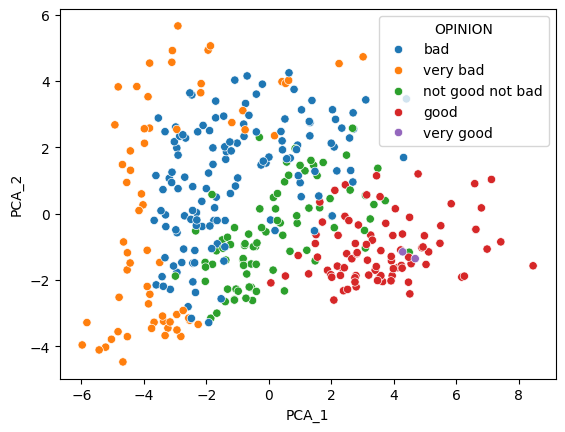

In [78]:

sns.scatterplot(data = df_pca, x = 'PCA_1', y = 'PCA_2', hue = 'OPINION')

In [83]:
model = KNeighborsClassifier()

In [90]:
#NON PCa

X_train, X_test, y_train, y_test = train_test_split(X_scaled ,y, stratify = y)

In [91]:
model_KN = model.fit(X_train, y_train)

In [92]:
y_pred_kn = model_KN.predict(X_test)

In [94]:
classification_kn = classification_report(y_test, y_pred_kn)
print(classification_report(y_test, y_pred_kn))

                  precision    recall  f1-score   support

             bad       0.74      0.76      0.75        33
            good       0.77      0.91      0.83        22
not good not bad       0.57      0.57      0.57        21
        very bad       0.91      0.62      0.74        16

        accuracy                           0.73        92
       macro avg       0.75      0.72      0.72        92
    weighted avg       0.74      0.73      0.73        92



In [100]:
# Avec PCA

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y , stratify = y)

model_pca = model.fit(X_train_pca, y_train_pca)

y_pred_pca = model_pca.predict(X_test_pca)

In [103]:
classification_kn = classification_report(y_test, y_pred_kn)
classification_pca = classification_report(y_test_pca, y_pred_pca)
print(classification_report(y_test, y_pred_kn))
print('---------------------------------------------------------------')
print(f'{classification_pca}')

                  precision    recall  f1-score   support

             bad       0.74      0.76      0.75        33
            good       0.77      0.91      0.83        22
not good not bad       0.57      0.57      0.57        21
        very bad       0.91      0.62      0.74        16

        accuracy                           0.73        92
       macro avg       0.75      0.72      0.72        92
    weighted avg       0.74      0.73      0.73        92

---------------------------------------------------------------
                  precision    recall  f1-score   support

             bad       0.69      0.67      0.68        33
            good       0.81      0.95      0.88        22
not good not bad       0.65      0.71      0.68        21
        very bad       0.82      0.56      0.67        16

        accuracy                           0.73        92
       macro avg       0.74      0.72      0.73        92
    weighted avg       0.73      0.73      0.72        92

